# Cancer Diagnosis Prediction: Model Comparison Project

**Course:** Data Science (DNSC-3603 - 20018)  
**Instructor:** Hulisi Ogut  
**Group Members:** Taghi Mammadov (17503), Zakir Ashirli (17640)

This project uses the Breast Cancer Wisconsin dataset to predict whether a tumor is malignant or benign from medical measurements. The main goal is to compare multiple machine learning models, evaluate them with the metrics covered in class, and select a final model in a careful and explainable way.


In this problem, **recall for malignant cases is especially important** because a false negative means a malignant tumor was predicted as benign.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
from pathlib import Path

os.environ.setdefault("LOKY_MAX_CPU_COUNT", "1")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    silhouette_score,
    adjusted_rand_score,
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

try:
    from IPython.display import display
except ImportError:
    display = print

RANDOM_STATE = 42
plt.style.use("ggplot")
pd.set_option("display.max_columns", 40)


## 1. Load the Data

The dataset is loaded from `scikit-learn`, so the notebook runs without internet or extra files. A CSV copy available in the project GitHub repository.


In [2]:
project_dir = Path.cwd()
data_path = project_dir / "breast_cancer_project_data.csv"

raw = load_breast_cancer(as_frame=True)

X_original = raw.data.copy()
y_malignant = (raw.target == 0).astype(int)

df = X_original.copy()
df["diagnosis"] = np.where(y_malignant == 1, "malignant", "benign")
df.to_csv(data_path, index=False)

print(f"Dataset saved as: {data_path.name}")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
display(df.head())


Dataset saved as: breast_cancer_project_data.csv
Rows: 569
Columns: 31
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimen

## 2. Exploratory Data Analysis

We first look at class balance, missing values, and numeric summaries. This helps us understand whether the target is imbalanced and whether preprocessing is needed.


In [3]:
class_counts = df["diagnosis"].value_counts().rename_axis("diagnosis").reset_index(name="count")
class_counts["percent"] = (class_counts["count"] / len(df) * 100).round(2)

print("Class balance:")
display(class_counts)

print(f"Total missing values: {df.isna().sum().sum()}")

summary = df.drop(columns="diagnosis").describe().T[["mean", "std", "min", "50%", "max"]]
display(summary.head(10).round(2))


Class balance:
   diagnosis  count  percent
0     benign    357    62.74
1  malignant    212    37.26
Total missing values: 0
                          mean     std     min     50%      max
mean radius              14.13    3.52    6.98   13.37    28.11
mean texture             19.29    4.30    9.71   18.84    39.28
mean perimeter           91.97   24.30   43.79   86.24   188.50
mean area               654.89  351.91  143.50  551.10  2501.00
mean smoothness           0.10    0.01    0.05    0.10     0.16
mean compactness          0.10    0.05    0.02    0.09     0.35
mean concavity            0.09    0.08    0.00    0.06     0.43
mean concave points       0.05    0.04    0.00    0.03     0.20
mean symmetry             0.18    0.03    0.11    0.18     0.30
mean fractal dimension    0.06    0.01    0.05    0.06     0.10


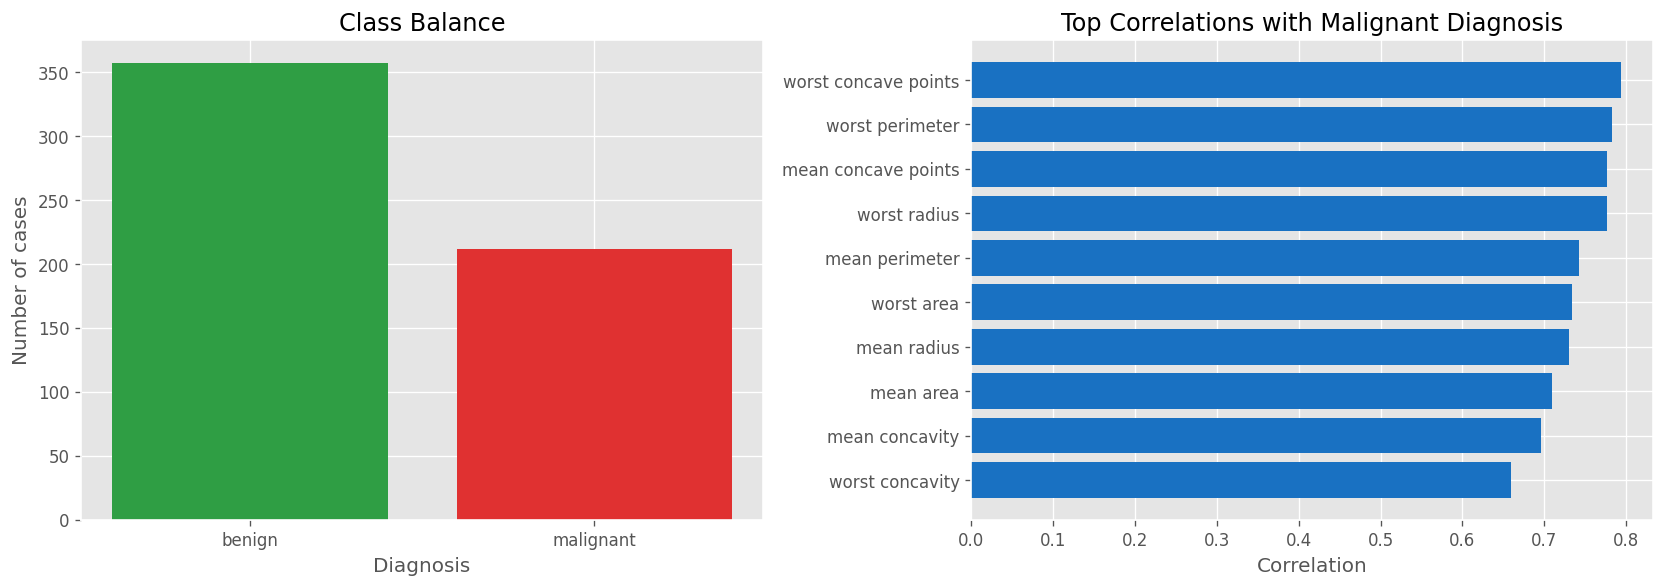

In [4]:
feature_cols = df.columns.drop("diagnosis")
y = (df["diagnosis"] == "malignant").astype(int)

correlations = df[feature_cols].corrwith(y).sort_values(key=lambda x: x.abs(), ascending=False)
top_corr = correlations.head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(class_counts["diagnosis"], class_counts["count"], color=["#2f9e44", "#e03131"])
axes[0].set_title("Class Balance")
axes[0].set_xlabel("Diagnosis")
axes[0].set_ylabel("Number of cases")

axes[1].barh(top_corr.index[::-1], top_corr.values[::-1], color="#1971c2")
axes[1].set_title("Top Correlations with Malignant Diagnosis")
axes[1].set_xlabel("Correlation")

plt.tight_layout()
plt.show()


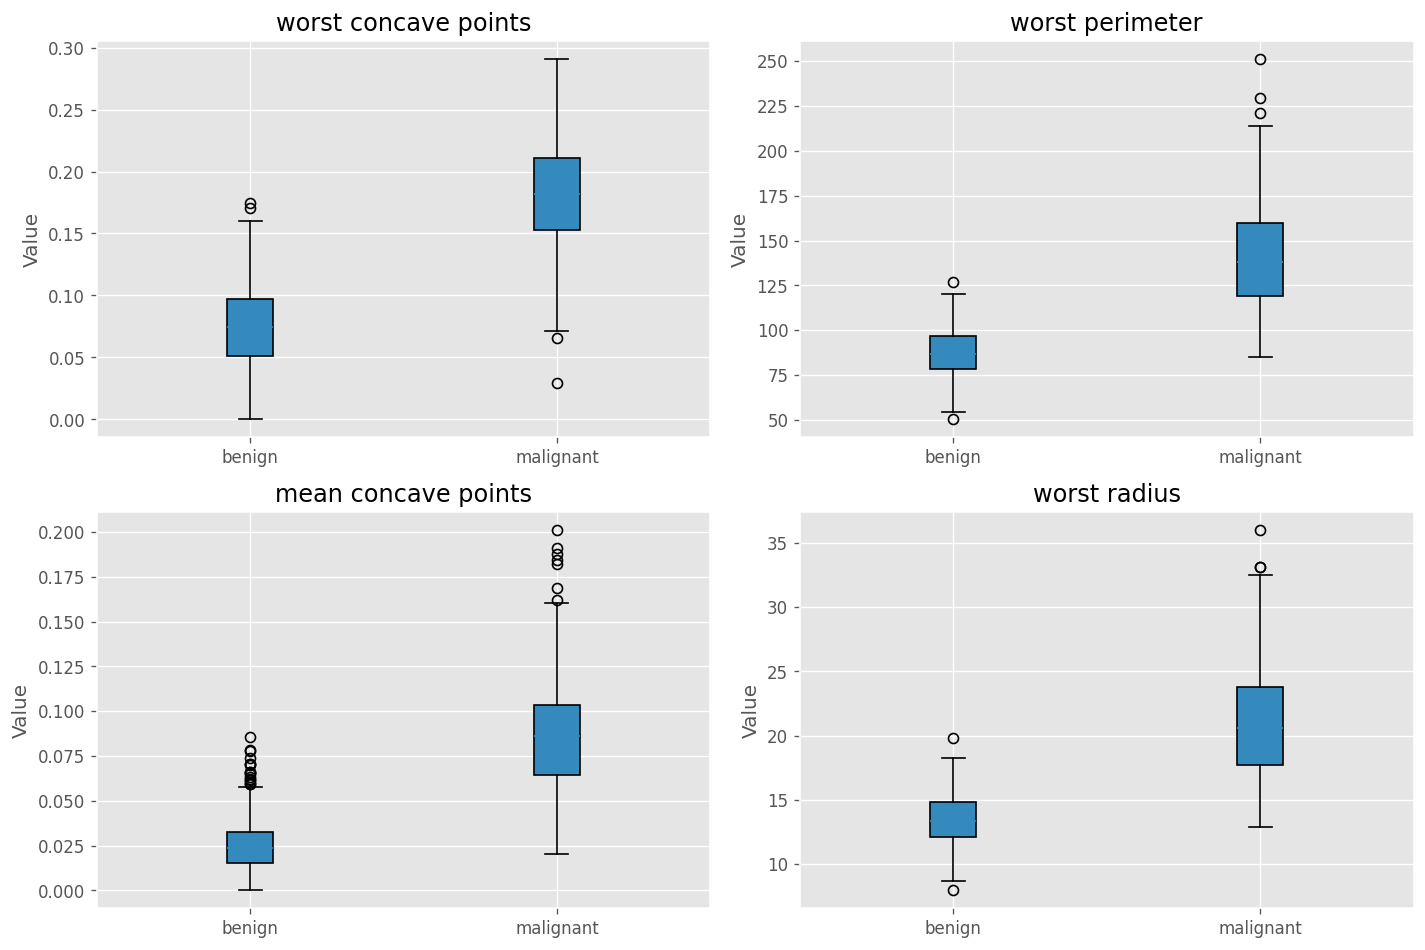

In [5]:
top_features = top_corr.head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for ax, feature in zip(axes, top_features):
    groups = [
        df.loc[df["diagnosis"] == "benign", feature],
        df.loc[df["diagnosis"] == "malignant", feature],
    ]
    ax.boxplot(groups, labels=["benign", "malignant"], patch_artist=True)
    ax.set_title(feature)
    ax.set_ylabel("Value")

plt.tight_layout()
plt.show()


## 3. Train-Test Split

We used a stratified split so both train and test data keep a similar malignant/benign ratio.


In [6]:
X = df[feature_cols]
y = (df["diagnosis"] == "malignant").astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Training rows: {X_train.shape[0]}")
print(f"Test rows: {X_test.shape[0]}")
print(f"Malignant rate in train: {y_train.mean():.3f}")
print(f"Malignant rate in test: {y_test.mean():.3f}")


Training rows: 426
Test rows: 143
Malignant rate in train: 0.373
Malignant rate in test: 0.371


## 4. Baseline Model Comparison

Some models need scaled variables, especially Logistic Regression, KNN, SVM, and Naive Bayes. Tree-based models do not require scaling, so they are trained directly.


In [7]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ]),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier()),
    ]),
    "Naive Bayes": Pipeline([
        ("scaler", StandardScaler()),
        ("model", GaussianNB()),
    ]),
    "SVM (RBF)": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE)),
    ]),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

def positive_scores(model, X_data):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_data)[:, 1]
    if hasattr(model, "decision_function"):
        return model.decision_function(X_data)
    return model.predict(X_data)

def evaluate_model(name, model, X_test, y_test, cv_auc):
    y_pred = model.predict(X_test)
    y_score = positive_scores(model, X_test)
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_score),
        "CV ROC-AUC": cv_auc,
    }

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
fitted_models = {}
rows = []

for name, model in models.items():
    model.fit(X_train, y_train)
    cv_auc = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc").mean()
    rows.append(evaluate_model(name, model, X_test, y_test, cv_auc))
    fitted_models[name] = model

results_df = pd.DataFrame(rows).sort_values(
    ["ROC-AUC", "Recall", "F1"],
    ascending=False,
)

display(results_df.round(3))


                 Model  Accuracy  Precision  Recall     F1  ROC-AUC  \
3            SVM (RBF)     0.972      1.000   0.925  0.961    0.997   
0  Logistic Regression     0.965      0.980   0.925  0.951    0.996   
5        Random Forest     0.958      1.000   0.887  0.940    0.995   
7    Gradient Boosting     0.965      1.000   0.906  0.950    0.995   
6             AdaBoost     0.979      1.000   0.943  0.971    0.994   
2          Naive Bayes     0.944      0.959   0.887  0.922    0.992   
1                  KNN     0.958      0.980   0.906  0.941    0.986   
4        Decision Tree     0.958      0.980   0.906  0.941    0.947   

   CV ROC-AUC  
3       0.994  
0       0.991  
5       0.987  
7       0.986  
6       0.994  
2       0.986  
1       0.983  
4       0.912  


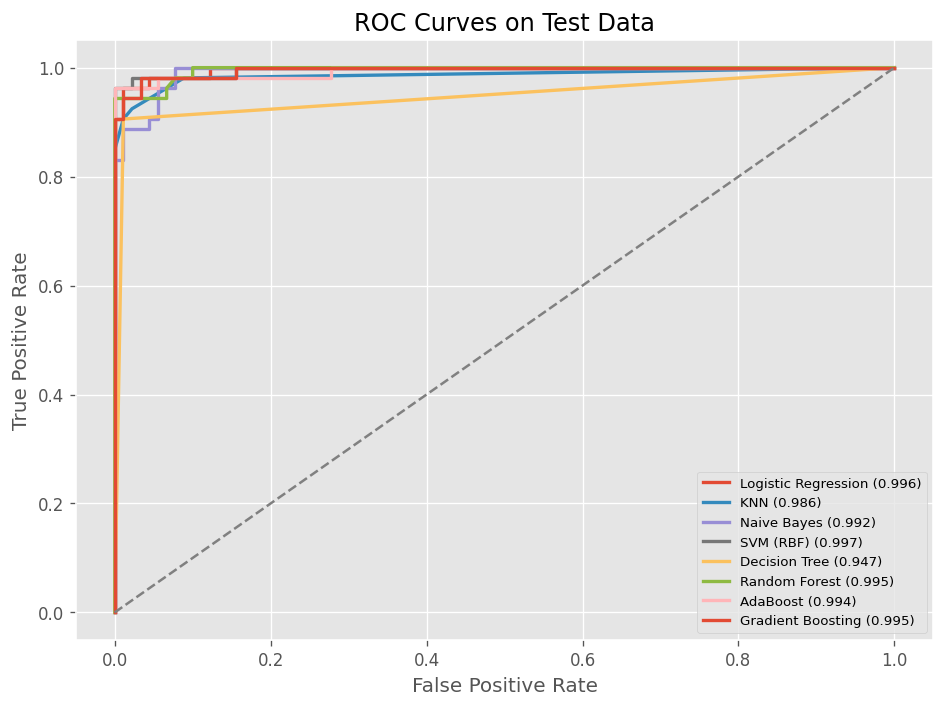

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, model in fitted_models.items():
    y_score = positive_scores(model, X_test)
    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc = roc_auc_score(y_test, y_score)
    ax.plot(fpr, tpr, linewidth=2, label=f"{name} ({auc:.3f})")

ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax.set_title("ROC Curves on Test Data")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


Best baseline model by ROC-AUC: SVM (RBF)
False negatives: 4
False positives: 0


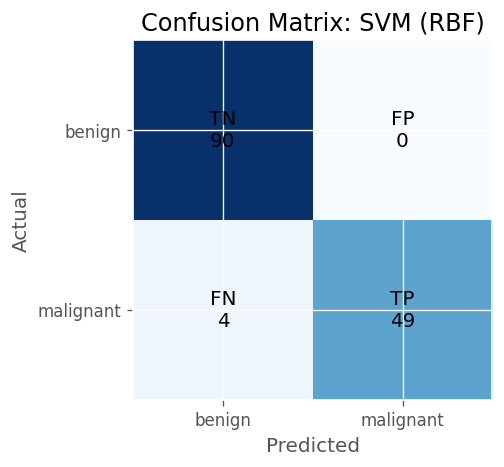

In [9]:
best_initial_name = results_df.iloc[0]["Model"]
best_initial_model = fitted_models[best_initial_name]
initial_pred = best_initial_model.predict(X_test)
cm = confusion_matrix(y_test, initial_pred)
tn, fp, fn, tp = cm.ravel()

print(f"Best baseline model by ROC-AUC: {best_initial_name}")
print(f"False negatives: {fn}")
print(f"False positives: {fp}")

fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(cm, cmap="Blues")
ax.set_title(f"Confusion Matrix: {best_initial_name}")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["benign", "malignant"])
ax.set_yticklabels(["benign", "malignant"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

labels = np.array([["TN", "FP"], ["FN", "TP"]])
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{labels[i, j]}\n{cm[i, j]}", ha="center", va="center", fontsize=12)

plt.tight_layout()
plt.show()


## 5. Hyperparameter Tuning

We tuned four strong candidates using GridSearchCV. The scoring metric is ROC-AUC because it evaluates ranking quality across thresholds. After tuning, we still pay special attention to recall because missing malignant cases is the more serious error.


In [10]:
tuning_grids = {
    "Logistic Regression": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=3000, random_state=RANDOM_STATE)),
        ]),
        {"model__C": [0.05, 0.1, 1, 3]},
    ),
    "SVM (RBF)": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE)),
        ]),
        {"model__C": [1, 2], "model__gamma": ["scale", 0.01]},
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=RANDOM_STATE),
        {
            "n_estimators": [150],
            "max_depth": [None, 6],
            "min_samples_leaf": [1, 3],
        },
    ),
    "Gradient Boosting": (
        GradientBoostingClassifier(random_state=RANDOM_STATE),
        {
            "n_estimators": [80, 150],
            "learning_rate": [0.03, 0.1],
            "max_depth": [2, 3],
        },
    ),
}

tuning_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
tuned_models = {}
tuned_rows = []
best_params = {}

for name, (model, param_grid) in tuning_grids.items():
    search = GridSearchCV(
        model,
        param_grid,
        scoring="roc_auc",
        cv=tuning_cv,
        n_jobs=1,
    )
    search.fit(X_train, y_train)

    best_model = search.best_estimator_
    tuned_models[name] = best_model
    best_params[name] = search.best_params_
    tuned_rows.append(evaluate_model(name, best_model, X_test, y_test, search.best_score_))

tuned_results = pd.DataFrame(tuned_rows).sort_values(
    ["Recall", "ROC-AUC", "F1"],
    ascending=False,
)

display(tuned_results.round(3))

for name, params in best_params.items():
    print(f"{name}: {params}")


                 Model  Accuracy  Precision  Recall     F1  ROC-AUC  \
0  Logistic Regression     0.979        1.0   0.943  0.971    0.998   
1            SVM (RBF)     0.979        1.0   0.943  0.971    0.996   
2        Random Forest     0.965        1.0   0.906  0.950    0.995   
3    Gradient Boosting     0.965        1.0   0.906  0.950    0.994   

   CV ROC-AUC  
0       0.992  
1       0.995  
2       0.986  
3       0.987  
Logistic Regression: {'model__C': 0.1}
SVM (RBF): {'model__C': 2, 'model__gamma': 'scale'}
Random Forest: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 150}
Gradient Boosting: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 150}


## 6. Final Model and Threshold Check

The final model is chosen by first prioritizing recall, then ROC-AUC, then F1-score. This matches the project context because false negatives are the most costly mistake.


In [11]:
final_name = tuned_results.iloc[0]["Model"]
final_model = tuned_models[final_name]
final_metrics = tuned_results.set_index("Model").loc[final_name]

final_scores = positive_scores(final_model, X_test)
final_pred = final_model.predict(X_test)
final_cm = confusion_matrix(y_test, final_pred)
tn, fp, fn, tp = final_cm.ravel()

print(f"Final selected model: {final_name}")
print(f"Accuracy: {final_metrics['Accuracy']:.3f}")
print(f"Precision: {final_metrics['Precision']:.3f}")
print(f"Recall: {final_metrics['Recall']:.3f}")
print(f"F1-score: {final_metrics['F1']:.3f}")
print(f"ROC-AUC: {final_metrics['ROC-AUC']:.3f}")
print(f"False negatives at default threshold: {fn}")
print(f"False positives at default threshold: {fp}")


Final selected model: Logistic Regression
Accuracy: 0.979
Precision: 1.000
Recall: 0.943
F1-score: 0.971
ROC-AUC: 0.998
False negatives at default threshold: 3
False positives at default threshold: 0


In [12]:
threshold_rows = []

for threshold in [0.30, 0.40, 0.50, 0.60, 0.70]:
    pred_at_threshold = (final_scores >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred_at_threshold).ravel()
    threshold_rows.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, pred_at_threshold),
        "Recall": recall_score(y_test, pred_at_threshold),
        "F1": f1_score(y_test, pred_at_threshold),
        "False Negatives": fn,
        "False Positives": fp,
    })

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df.round(3))


   Threshold  Precision  Recall     F1  False Negatives  False Positives
0        0.3      0.945   0.981  0.963                1                3
1        0.4      1.000   0.981  0.990                1                0
2        0.5      1.000   0.943  0.971                3                0
3        0.6      1.000   0.906  0.950                5                0
4        0.7      1.000   0.868  0.929                7                0


## 7. Feature Importance

Permutation importance shows which variables matter most for the final model on the test set. The idea is simple: if shuffling a feature hurts ROC-AUC a lot, the model was relying on that feature.


                 Feature  Importance
27  worst concave points      0.0019
21         worst texture      0.0017
20          worst radius      0.0015
22       worst perimeter      0.0013
28        worst symmetry      0.0012
26       worst concavity      0.0011
7    mean concave points      0.0011
23            worst area      0.0009
24      worst smoothness      0.0009
2         mean perimeter      0.0006


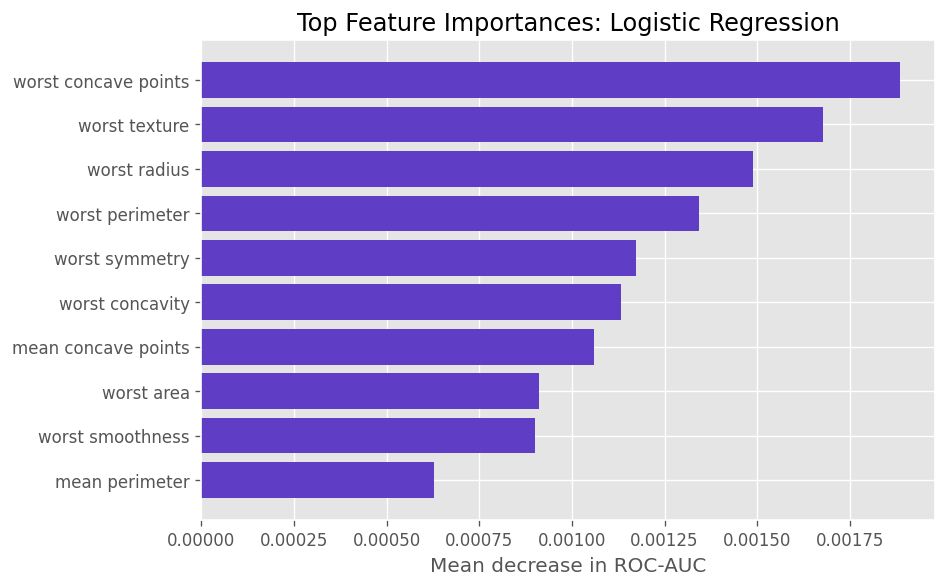

In [13]:
perm = permutation_importance(
    final_model,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=20,
    random_state=RANDOM_STATE,
)

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": perm.importances_mean,
}).sort_values("Importance", ascending=False)

display(importance_df.head(10).round(4))

top_importance = importance_df.head(10).iloc[::-1]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top_importance["Feature"], top_importance["Importance"], color="#5f3dc4")
ax.set_title(f"Top Feature Importances: {final_name}")
ax.set_xlabel("Mean decrease in ROC-AUC")
plt.tight_layout()
plt.show()


## 8. PCA and KMeans Extension

To connect the classification task with unsupervised learning, I reduce the 30 variables into two principal components and then apply KMeans with two clusters. This does not use the labels during clustering, so it checks whether the structure of the measurements naturally separates the two diagnosis groups.


Variance explained by first two PCs: 0.632
KMeans silhouette score: 0.343
Adjusted Rand Index vs actual labels: 0.654


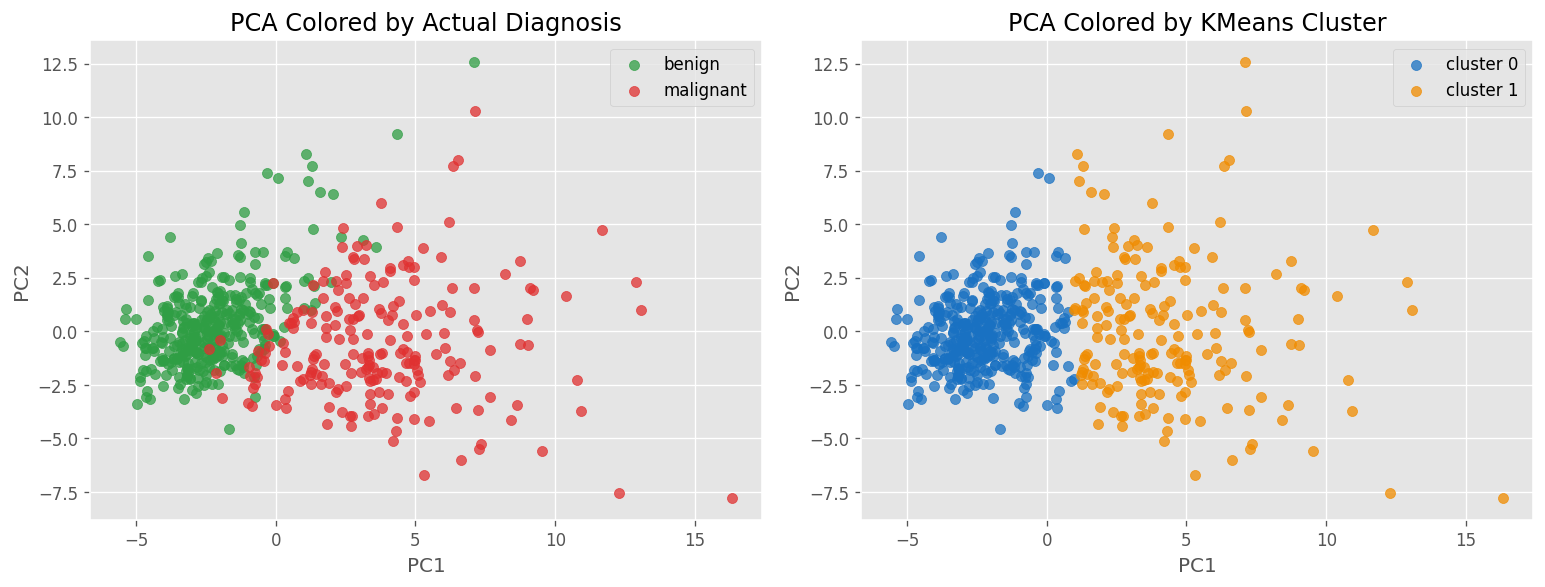

In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": components[:, 0],
    "PC2": components[:, 1],
    "diagnosis": df["diagnosis"],
    "malignant": y,
})

kmeans = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
pca_df["cluster"] = kmeans.fit_predict(X_scaled)

explained = pca.explained_variance_ratio_.sum()
sil = silhouette_score(X_scaled, pca_df["cluster"])
ari = adjusted_rand_score(y, pca_df["cluster"])

print(f"Variance explained by first two PCs: {explained:.3f}")
print(f"KMeans silhouette score: {sil:.3f}")
print(f"Adjusted Rand Index vs actual labels: {ari:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for diagnosis, color in [("benign", "#2f9e44"), ("malignant", "#e03131")]:
    part = pca_df[pca_df["diagnosis"] == diagnosis]
    axes[0].scatter(part["PC1"], part["PC2"], label=diagnosis, alpha=0.75, color=color)

axes[0].set_title("PCA Colored by Actual Diagnosis")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend()

for cluster, color in [(0, "#1971c2"), (1, "#f08c00")]:
    part = pca_df[pca_df["cluster"] == cluster]
    axes[1].scatter(part["PC1"], part["PC2"], label=f"cluster {cluster}", alpha=0.75, color=color)

axes[1].set_title("PCA Colored by KMeans Cluster")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].legend()

plt.tight_layout()
plt.show()


   k  silhouette_score
0  2             0.343
1  3             0.314
2  4             0.283
3  5             0.158
4  6             0.160
5  7             0.153


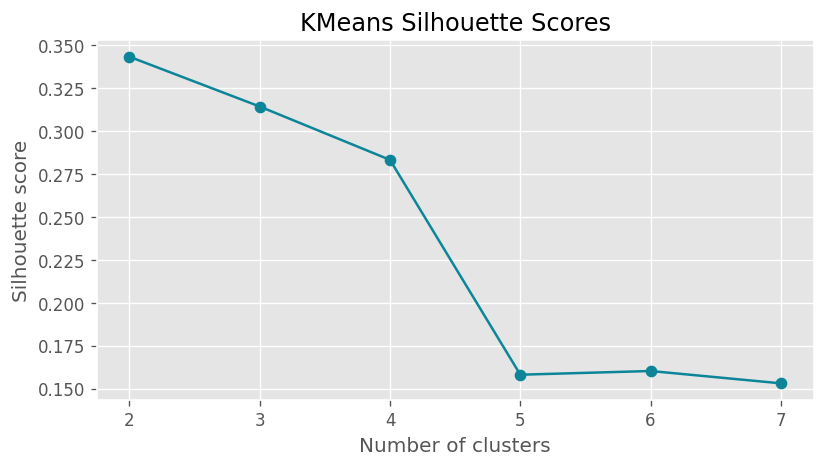

In [15]:
silhouette_rows = []

for k in range(2, 8):
    labels = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit_predict(X_scaled)
    silhouette_rows.append({
        "k": k,
        "silhouette_score": silhouette_score(X_scaled, labels),
    })

silhouette_df = pd.DataFrame(silhouette_rows)
display(silhouette_df.round(3))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(silhouette_df["k"], silhouette_df["silhouette_score"], marker="o", color="#0c8599")
ax.set_title("KMeans Silhouette Scores")
ax.set_xlabel("Number of clusters")
ax.set_ylabel("Silhouette score")
plt.tight_layout()
plt.show()


## Conclusion

This project compared several models from the course, including linear, distance-based, probabilistic, tree-based, bagging, and boosting methods. The final model was selected using test-set performance and the practical meaning of errors. In this dataset, recall matters strongly because a false negative means a malignant case was missed.

The PCA and KMeans section also shows that the measurements contain visible structure even without using the target labels. Overall, the analysis supports a full data science workflow: data understanding, preprocessing, model comparison, evaluation, tuning, interpretation, and a short unsupervised learning extension.

**Dataset reference:** Breast Cancer Wisconsin Diagnostic dataset, available through `sklearn.datasets.load_breast_cancer`.
